# Multimodal RAG: Text and Images

This notebook demonstrates a **multimodal RAG pipeline** that retrieves both text and images from a PDF document to answer questions.

**Pipeline overview:**
1. Parse a PDF into text and image chunks
2. Embed text chunks with a sentence transformer, image chunks with a vision-language model
3. Store both in separate ChromaDB vector stores
4. Retrieve relevant chunks (text + images) using a composite retriever
5. Pass retrieved content to an LLM for a grounded answer

# Setup

In [1]:
import os
import io
import shutil
import base64

import matplotlib.pyplot as plt

from conversational_toolkit.chunking.pdf_chunker import PDFChunker

from conversational_toolkit.embeddings.sentence_transformer import (
    SentenceTransformerEmbeddings,
)
from conversational_toolkit.embeddings.qwen_vl import Qwen3VLEmbeddings
from conversational_toolkit.vectorstores.chromadb import ChromaDBVectorStore
from conversational_toolkit.retriever.vectorstore_retriever import (
    CompositeVectorStoreRetriever,
)

from conversational_toolkit.llms.base import LLMMessage, MessageContent, Roles
from conversational_toolkit.llms.openai import OpenAILLM

from conversational_toolkit.agents.base import QueryWithContext
from conversational_toolkit.agents.rag import RAG

# 1. Parse Document and Chunk

`PDFChunker` splits the PDF into text and image chunks. With `write_images=True`, embedded images are extracted too. Their binary image data is stored as **base64-encoded text**, which makes it easy to keep images in a text-based chunk structure. To display an image, decode the base64 string back into bytes first.


In [ ]:
chunker = PDFChunker()

chunks = chunker.make_chunks(
    "../../data/EPD_cardboard_redbox_cartonpallet.pdf",  # example document
    write_images=True,
    image_path="../../data/tmp_images/",
)

objc[45989]: Class AVFFrameReceiver is implemented in both /Users/pkoerner/Desktop/Kanton_Zurich/rag_venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x13a2a43a8) and /Users/pkoerner/Desktop/Kanton_Zurich/rag_venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1431dc3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[45989]: Class AVFAudioReceiver is implemented in both /Users/pkoerner/Desktop/Kanton_Zurich/rag_venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x13a2a43f8) and /Users/pkoerner/Desktop/Kanton_Zurich/rag_venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1431dc3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


Chunk 0: ## Environmental Product Declaration (text/markdown)
Chunk 1: ## CARDBOARD BOX CARTONPALLET CMP ROSERIO (text/markdown)
Chunk 2: ## REDBOX Srl (text/markdown)
Chunk 3: ## Programme information (text/markdown)
Chunk 4: ## Accountabilities for PCR, LCA and independent, third-party verification (text/markdown)
Chunk 5: ## Product Category Rules (PCR) (text/markdown)
Chunk 6: ## Life Cycle Assessment (LCA) (text/markdown)
Chunk 7: ## Third-party verification (text/markdown)
Chunk 8: ## Name and contact information of LCA practitioners: (text/markdown)
Chunk 9: ## Company information (text/markdown)
Chunk 10: ## Description of the organisation: (text/markdown)
Chunk 11: ## Product information (text/markdown)
Chunk 12: ## Product description and identification: (text/markdown)
Chunk 13: ## LCA information (text/markdown)
Chunk 14: ## Data quality (text/markdown)
Chunk 15: ## System diagram: (text/markdown)
Chunk 16: ## Description of system boundaries: cradle-to-grave. (text/markdow

/var/folders/wc/vr2d5w_x7z783sr5x3959rh80000gn/T/ipykernel_45989/2547253317.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 8))


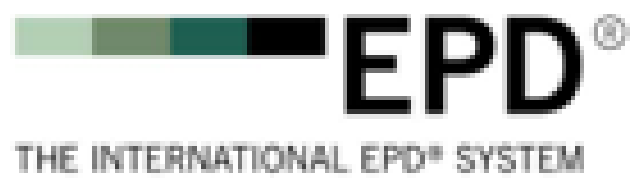

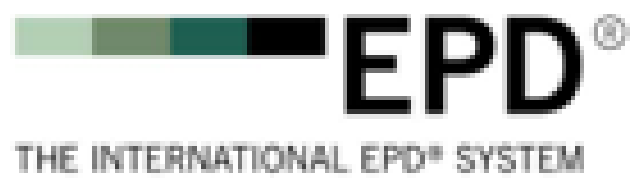

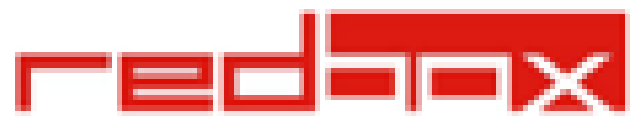

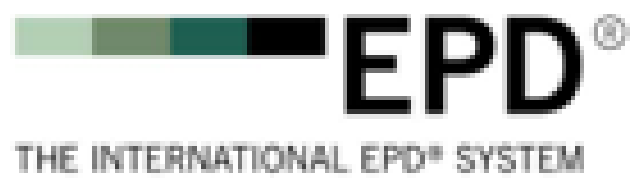

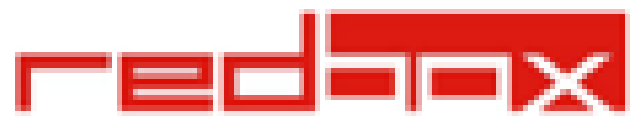

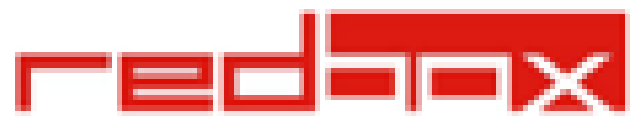

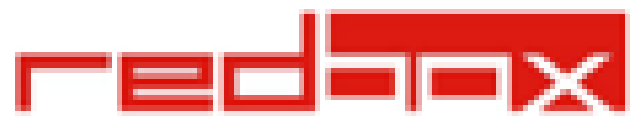

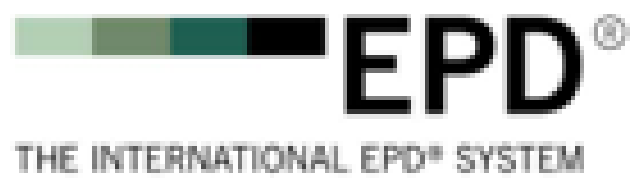

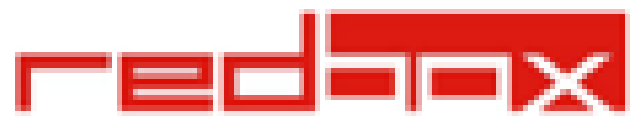

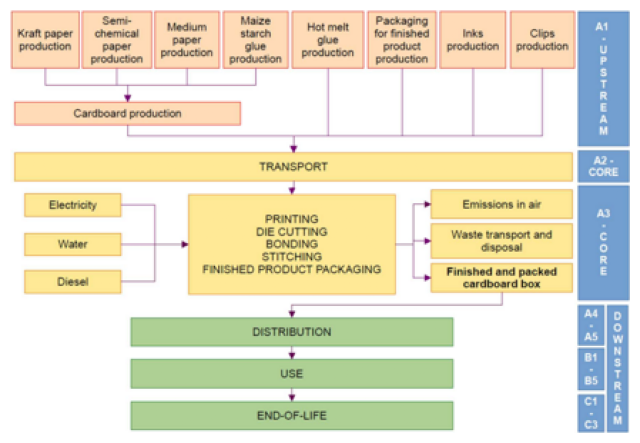

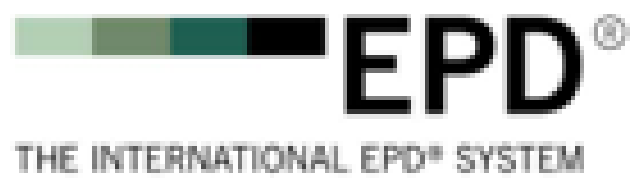

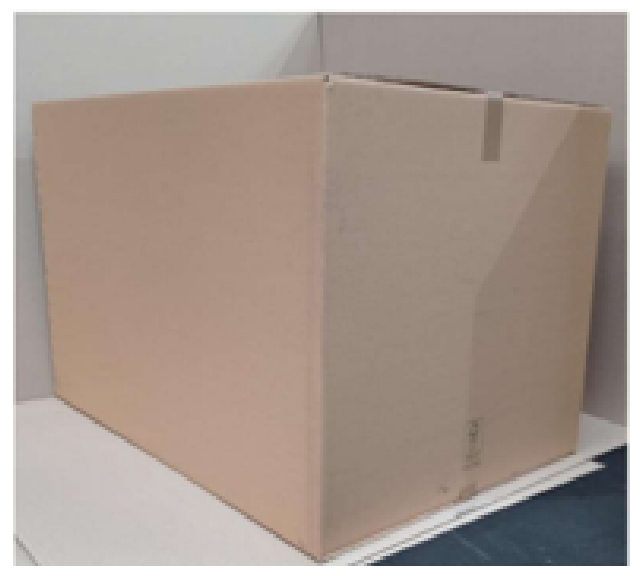

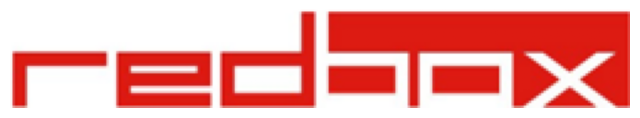

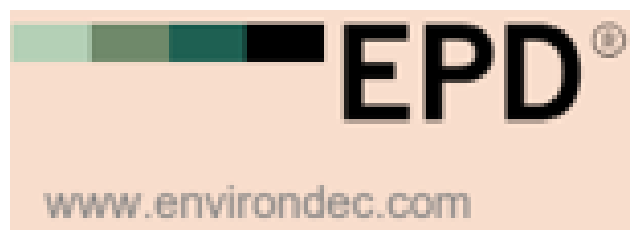

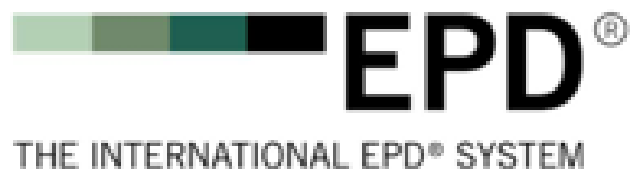

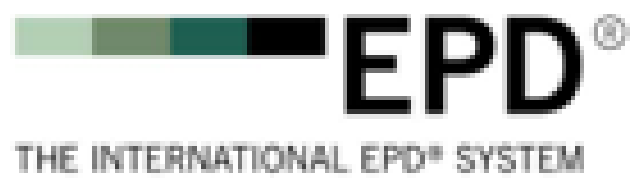

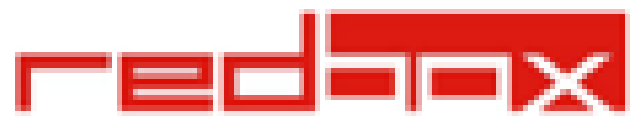

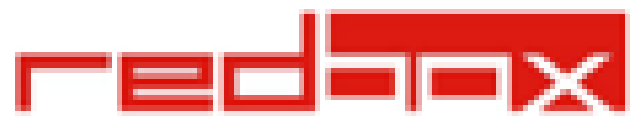

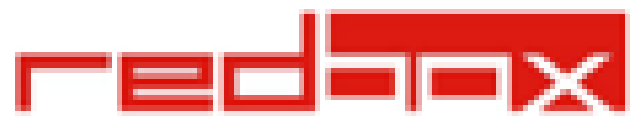

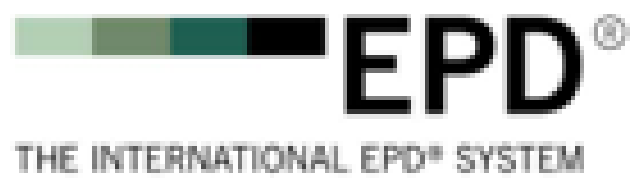

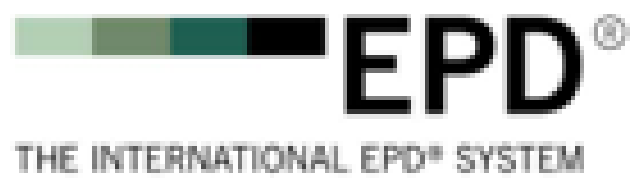

In [4]:
for i, chunk in enumerate(chunks):
    print(f"Chunk {i}: {chunk.title} ({chunk.mime_type})")
    if chunk.mime_type.startswith("image/"):
        image_data = base64.b64decode(chunk.content)

        image = plt.imread(io.BytesIO(image_data), format=chunk.mime_type.split("/")[1])

        plt.figure(figsize=(8, 8))
        plt.imshow(image)
        plt.axis("off")

plt.show()

# 2. Embed Text

Text chunks are embedded with `sentence-transformers/all-MiniLM-L6-v2` (384-dim vectors) and stored in a ChromaDB collection. A quick similarity search validates retrieval quality.

In [5]:
text_embedding_model = SentenceTransformerEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

if os.path.exists("../../db/db_text_tmp/"):
    shutil.rmtree("../../db/db_text_tmp/")
text_vector_store = ChromaDBVectorStore(db_path="../../db/db_text_tmp/")

text_chunks = [c for c in chunks if c.mime_type.startswith("text/")]

embeddings = await text_embedding_model.get_embeddings([c.content for c in text_chunks])

await text_vector_store.insert_chunks(chunks=text_chunks, embedding=embeddings)

print(sum(len(e) for e in embeddings))

2026-03-23 16:53:54.469 | DEBUG    | conversational_toolkit.embeddings.sentence_transformer:__init__:54 - Sentence Transformer embeddings model loaded: sentence-transformers/all-MiniLM-L6-v2 with kwargs: {}
2026-03-23 16:53:54.763 | DEBUG    | conversational_toolkit.embeddings.sentence_transformer:get_embeddings:65 - sentence-transformers/all-MiniLM-L6-v2 embeddings size: (29, 384)


11136


In [ ]:
query = "What is the amount of PBT/vPvB substances?"

query_embedding = await text_embedding_model.get_embeddings(query)

results = await text_vector_store.get_chunks_by_embedding(query_embedding, top_k=5)

print(len(results))

for i, result in enumerate(results):
    print(f"Result {i}: {result.title} ({result.mime_type})")

print(results[0].content)

2026-03-23 16:53:54.836 | DEBUG    | conversational_toolkit.embeddings.sentence_transformer:get_embeddings:65 - sentence-transformers/all-MiniLM-L6-v2 embeddings size: (1, 384)


5
Result 0: ## Product description and identification: (text/markdown)
Result 1: ## Environmental Product Declaration (text/markdown)
Result 2: ## Waste indicators (text/markdown)
Result 3: ## Product (text/markdown)
Result 4: ## Description of the organisation: (text/markdown)
## Product description and identification:

The  product  is  a  corrugated  cardboard  box  (2  waves),  printed,  glued  and  stapled,  measuring 1180x790x772 mm.

UN CPC code: 32153 'Cartons, boxes, cases, record sleeves and other packing containers (except bags) of paper, paperboard, cellulose wadding or webs of cellulose fibres; box files, letter trays, and similar articles, of paper or paperboard of a kind used in offices, shops or the like'

The product does not contain PBT/vPvB substances ≥ 0.1% evaluated in accordance with Annex XIII of REACH and does not contain any substances listed on the REACH candidate list.

Geographical scope: Italy




# 3. Embed Images

Image chunks are embedded with `Qwen3VLEmbeddings`, a vision-language model that produces embeddings aligned with text. This allows querying images using natural language (e.g. `get_text_embeddings` encodes the query, `get_embeddings` encodes the images).

In [7]:
# image_embedding_model = CLIPEmbeddings()
image_embedding_model = Qwen3VLEmbeddings()

if os.path.exists("../../db/db_image_tmp/"):
    shutil.rmtree("../../db/db_image_tmp/")

image_vector_store = ChromaDBVectorStore(db_path="../../db/db_image_tmp/")

image_chunks = [c for c in chunks if c.mime_type.startswith("image/")]

embeddings = await image_embedding_model.get_embeddings([c for c in image_chunks])

await image_vector_store.insert_chunks(chunks=image_chunks, embedding=embeddings)

print(sum(len(e) for e in embeddings))

43008


Result 0: EPD_cardboard_redbox_cartonpallet-picture-16.png (image/png)
Result 1: EPD_cardboard_redbox_cartonpallet-picture-8.png (image/png)
Result 2: EPD_cardboard_redbox_cartonpallet-picture-17.png (image/png)
Result 3: EPD_cardboard_redbox_cartonpallet-picture-19.png (image/png)
Result 4: EPD_cardboard_redbox_cartonpallet-picture-6.png (image/png)


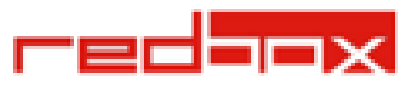

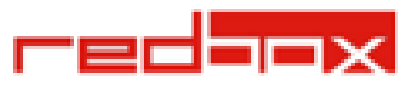

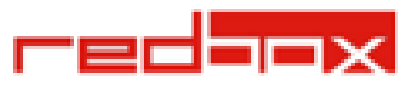

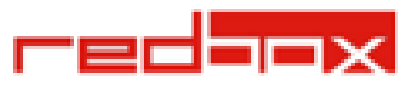

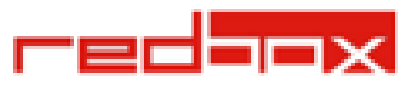

In [24]:
query = "The logo of a company"
# query = "The EPD logo"
# query = "A carton box on a table"
# query = "A diagram about the product history"

query_embedding = await image_embedding_model.get_text_embeddings(query)

results = await image_vector_store.get_chunks_by_embedding(query_embedding, top_k=5)

for i, result in enumerate(results):
    print(f"Result {i}: {result.title} ({result.mime_type})")
    image_data = base64.b64decode(result.content)

    image = plt.imread(io.BytesIO(image_data), format=result.mime_type.split("/")[1])

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")

# 4. Composite Retrieval

`CompositeVectorStoreRetriever` queries both vector stores in one call and merges the results. Here we retrieve the top 2 text chunks and top 1 image chunk per query.

2026-03-23 17:00:32.547 | DEBUG    | conversational_toolkit.embeddings.sentence_transformer:get_embeddings:65 - sentence-transformers/all-MiniLM-L6-v2 embeddings size: (1, 384)


Result 0 - type: text/markdown
## Product description and identification:

The  product  is  a  corrugated  cardboard  box  (2  waves),  printed,  glued  and  stapled,  measuring 1180x790x772 mm.

UN CPC code: 32153 'Cartons, boxes, cases, record sleeves and other packing containers (except bags) of paper, paperboard, cellulose wadding or webs of cellulose fibres; box files, letter trays, and similar articles, of paper or paperboard of a kind used in offices, shops or the like'

The product does not contain PBT/vPvB substances ≥ 0.1% evaluated in accordance with Annex XIII of REACH and does not contain any substances listed on the REACH candidate list.

Geographical scope: Italy


Result 1 - type: text/markdown
## Environmental Product Declaration

In accordance with ISO 14025:2006 for:


Result 2 - type: text/markdown
## Waste indicators

The following results are valid for 1 Cartonpallet CMP Roserio:

| Parameter                    | Unit   | Upstream   | Core     | Downstream   | To

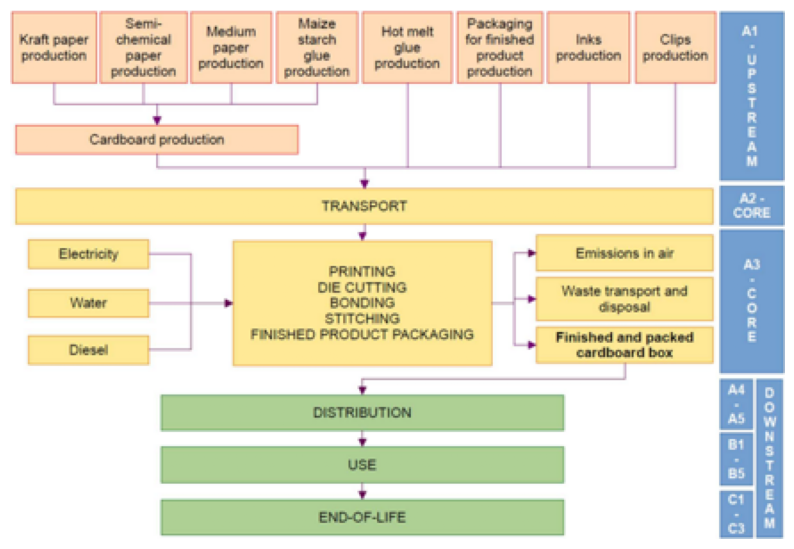

In [ ]:
query = "What is the amount of PBT/vPvB substances?"

composite_retriever = CompositeVectorStoreRetriever(
    embedding_models=[text_embedding_model, image_embedding_model],
    vector_stores=[text_vector_store, image_vector_store],
    top_k=[3, 1],
)

results = await composite_retriever.retrieve(query)

for i, result in enumerate(results):
    # if text print it
    print(f"Result {i} - type: {result.mime_type}")

    if result.mime_type.startswith("text/"):
        print(result.content)
    elif result.mime_type.startswith("image/"):
        image_data = base64.b64decode(result.content)

        image = plt.imread(
            io.BytesIO(image_data), format=result.mime_type.split("/")[1]
        )

        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis("off")

# 5. Send Image to LLM

A multimodal message is built with `MessageContent` blocks, one for the text prompt and one for the image (base64). Both `generate` (single response) and `generate_stream` (streaming) are shown.

2026-03-23 16:54:43.633 | DEBUG    | conversational_toolkit.llms.openai:__init__:90 - OpenAI LLM loaded: gpt-4o-mini; temperature: 0.5; seed: 42; tools: None; tool_choice: None; response_format: {'type': 'text'}


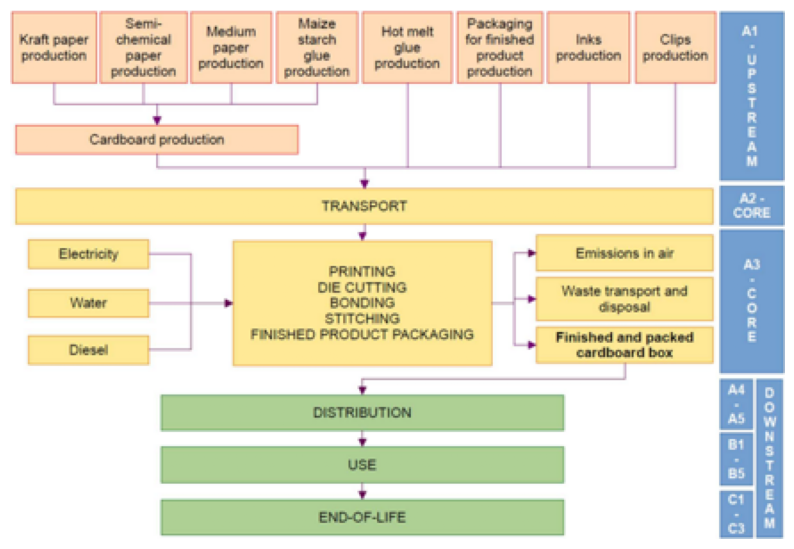

In [10]:
llm = OpenAILLM()

image_as_base64 = results[-1].content
image_data = base64.b64decode(image_as_base64)
image = plt.imread(io.BytesIO(image_data), format=results[-1].mime_type.split("/")[1])
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

In [11]:
test_messages = [
    LLMMessage(
        content=[
            MessageContent(
                type="input_text",
                text="What is in this image?",
            ),
            MessageContent(
                type="input_image",
                image_url=image_as_base64,
            ),
        ],
        role=Roles.USER,
    ),
]

In [12]:
answer = await llm.generate(test_messages)

print("\n\nAnswer content:")
print(answer.content)

2026-03-23 16:54:49.811 | DEBUG    | conversational_toolkit.llms.openai:generate:114 - Completion: ChatCompletion(id='chatcmpl-DMbu0aSbqtJCifLGepJQIMNogNRPh', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='The image appears to be a flowchart or diagram related to the production and lifecycle of cardboard boxes. It outlines various stages involved in the process, including:\n\n1. **Upstream Processes (A1)**: This section lists the production of materials like kraft paper, semi-chemical paper, and glue.\n\n2. **Core Processes (A2)**: This includes transport and the main printing and packaging processes, detailing resources like electricity, water, and diesel used in these stages.\n\n3. **Downstream Processes (A3)**: This section discusses emissions, waste disposal, and the final product, which is a finished and packed cardboard box.\n\n4. **Distribution, Use, and End-of-Life (A4, B1, B5, C1, C3)**: These categories likely refer to the



Answer content:
[MessageContent(type='text', text='The image appears to be a flowchart or diagram related to the production and lifecycle of cardboard boxes. It outlines various stages involved in the process, including:\n\n1. **Upstream Processes (A1)**: This section lists the production of materials like kraft paper, semi-chemical paper, and glue.\n\n2. **Core Processes (A2)**: This includes transport and the main printing and packaging processes, detailing resources like electricity, water, and diesel used in these stages.\n\n3. **Downstream Processes (A3)**: This section discusses emissions, waste disposal, and the final product, which is a finished and packed cardboard box.\n\n4. **Distribution, Use, and End-of-Life (A4, B1, B5, C1, C3)**: These categories likely refer to the logistics of distributing the boxes, their usage, and considerations for disposal or recycling at the end of their lifecycle.\n\nOverall, the diagram illustrates the entire lifecycle of cardboard production

In [28]:
answer_stream = llm.generate_stream(test_messages)

result = ""
async for chunk in answer_stream:
    # result += chunk.content[0].text if chunk.content else ""
    result += chunk.content[0].text or "" if chunk.content else ""

print("Answer content:\n")
print(result)

Answer content:

The image appears to be a flowchart or diagram related to the production and lifecycle of cardboard boxes. It outlines various stages involved in the process, including:

1. **Upstream Processes**: This includes the production of different types of paper (kraft, semi-chemical, medium, and maize starch glue) and components like packaging and clips.

2. **Transport**: This section highlights the resources used (electricity, water, diesel) and includes processes like printing, die cutting, bonding, stitching, and packaging.

3. **Core Processes**: This area focuses on the printing and packaging of finished products, along with emissions and waste management.

4. **Downstream**: This includes the distribution, use, and end-of-life stages of the cardboard boxes.

Overall, it illustrates the entire lifecycle from raw material production to the end-of-life disposal of cardboard boxes.


# 6. Full RAG Pipeline

The `RAG` agent wraps retrieval and generation end-to-end. Given a query it fetches relevant chunks (text + images) via the composite retriever and passes them as context to the LLM. The response includes both the answer and the source chunks used.

In [29]:
system_prompt = "You are a helpful assistant for answering questions about the content of documents. Use the following retrieved chunks to answer the question as best as you can. If you don't know the answer, say you don't know. Always use all available information from the retrieved chunks to provide a comprehensive answer."

agent = RAG(
    llm=llm,
    utility_llm=llm,
    system_prompt=system_prompt,
    retrievers=[composite_retriever],
    number_query_expansion=0,
)

2026-03-23 17:20:19.766 | DEBUG    | conversational_toolkit.embeddings.sentence_transformer:get_embeddings:65 - sentence-transformers/all-MiniLM-L6-v2 embeddings size: (1, 384)



 The product does not contain PBT/vPvB substances ≥ 0.1%.

Sources:
- ## Product description and identification: (text/markdown)
## Product description and identification:

The  product  is  a  corrugated  cardboard  box  (2  waves),  printed,  glued  and  stapled,  measuring 1180x790x772 mm.

UN CPC code: 32153 'Cartons, boxes, cases, record sleeves and other packing containers (except bags) of paper, paperboard, cellulose wadding or webs of cellulose fibres; box files, letter trays, and similar articles, of paper or paperboard of a kind used in offices, shops or the like'

The product does not contain PBT/vPvB substances ≥ 0.1% evaluated in accordance with Annex XIII of REACH and does not contain any substances listed on the REACH candidate list.

Geographical scope: Italy


- ## Environmental Product Declaration (text/markdown)
## Environmental Product Declaration

In accordance with ISO 14025:2006 for:


- ## Waste indicators (text/markdown)
## Waste indicators

The following resu

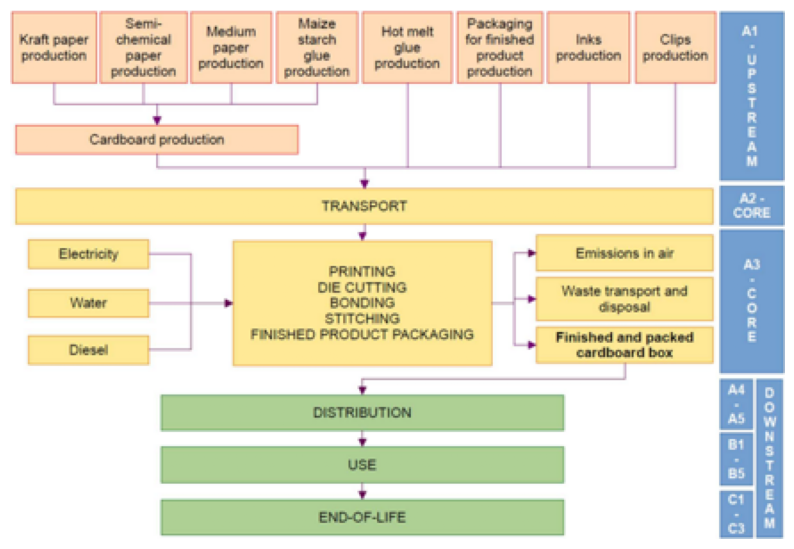

In [ ]:
query = "What is the amount of PBT/vPvB substances? Short answer."
query_with_context = QueryWithContext(query=query, history=[])

response = await agent.answer(query_with_context)

print("\n", response.content[0].text)

print("\nSources:\n")
for source in response.sources:
    print(f"- {source.title} ({source.mime_type})")
    if source.mime_type.startswith("text/"):
        print(source.content)
    elif source.mime_type.startswith("image/"):
        image_data = base64.b64decode(source.content)

        image = plt.imread(
            io.BytesIO(image_data), format=source.mime_type.split("/")[1]
        )

        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis("off")

2026-03-23 17:21:26.720 | DEBUG    | conversational_toolkit.embeddings.sentence_transformer:get_embeddings:65 - sentence-transformers/all-MiniLM-L6-v2 embeddings size: (1, 384)



 The percentage of glue in the product is 0.27%.

Sources:

- ## Product (text/markdown)
## Product

| Product component   | %     | |---------------------|-------| | Cardboard/paper     | 99,49 | | Inks                | 0,21  | | Glue                | 0,27  | | Clips               | 0,03  | | TOTAL               | 100   |


- ## Packaging (text/markdown)
## Packaging

The packaging included in the study for the final product is:

- -Packaging film - -Plastic strap - -Pallet.


- ## Product description and identification: (text/markdown)
## Product description and identification:

The  product  is  a  corrugated  cardboard  box  (2  waves),  printed,  glued  and  stapled,  measuring 1180x790x772 mm.

UN CPC code: 32153 'Cartons, boxes, cases, record sleeves and other packing containers (except bags) of paper, paperboard, cellulose wadding or webs of cellulose fibres; box files, letter trays, and similar articles, of paper or paperboard of a kind used in offices, shops or the like'

Th

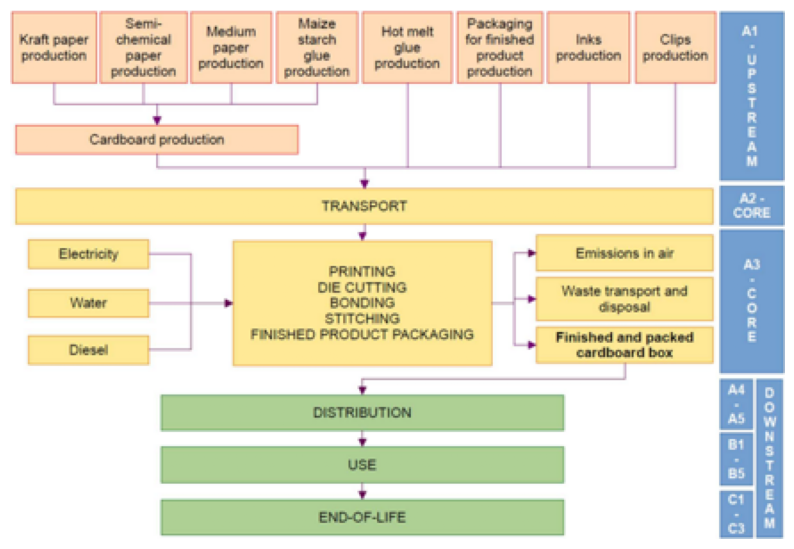

In [31]:
query = "What is the percentage of glue in the product? Short answer."
query_with_context = QueryWithContext(query=query, history=[])

response = await agent.answer(query_with_context)

print("\n", response.content[0].text)

print("\nSources:\n")
for source in response.sources:
    print(f"- {source.title} ({source.mime_type})")
    if source.mime_type.startswith("text/"):
        print(source.content)
    elif source.mime_type.startswith("image/"):
        image_data = base64.b64decode(source.content)

        image = plt.imread(
            io.BytesIO(image_data), format=source.mime_type.split("/")[1]
        )

        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis("off")

----------------------